# 02 — Data Augmentation (validação visual)

Objetivo: validar visualmente que as transformações de data augmentation funcionam corretamente, usando a biblioteca `albumentations`.

Este notebook NAO aplica ainda as transformacoes a nenhum split de treino/validacao/teste -- isso sera feito no notebook 03, depois que o split for definido. Aqui o objetivo e so confirmar que cada transformacao individual se comporta como esperado, olhando o antes/depois.

Transformacoes escolhidas: rotacao livre, flip horizontal, flip vertical, brilho/contraste, zoom leve. Distorcao elastica/warp foi excluida de proposito -- deformaria a propria estrutura do padrao, podendo mascarar ou criar defeitos falsos (risco especifico deste projeto).

 ## Imports

In [1]:
import albumentations as A
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Reprodutibilidade: mesmas transformacoes "aleatorias" a cada execucao.
np.random.seed(42)

## Carregamento das imagens de exemplo

In [2]:
# Caminho relativo: notebooks/ -> sobe um nivel -> dataset/
caminho_dataset = "../dataset"

# Pega o primeiro arquivo de cada classe, direto da pasta, so para
# fins de demonstracao visual (nao usa ImageFolder aqui, ja que
# so precisamos de 2 imagens especificas, nao o dataset inteiro).
caminho_correto = os.path.join(caminho_dataset, "correto", "correto_01.jpg")
caminho_erro = os.path.join(caminho_dataset, "erro", "erro_01.jpg")

# OpenCV le imagens no formato BGR (Azul-Verde-Vermelho) por padrao,
# mas matplotlib e a maioria das ferramentas esperam RGB. Por isso a
# conversao de cor logo em seguida -- sem ela, as cores apareceriam
# trocadas na visualizacao (efeito "negativo" azulado).
img_correto = cv2.imread(caminho_correto)
img_correto = cv2.cvtColor(img_correto, cv2.COLOR_BGR2RGB)

img_erro = cv2.imread(caminho_erro)
img_erro = cv2.cvtColor(img_erro, cv2.COLOR_BGR2RGB)

print(f"Imagem 'correto' carregada, formato: {img_correto.shape}")
print(f"Imagem 'erro' carregada, formato: {img_erro.shape}")

Imagem 'correto' carregada, formato: (512, 512, 3)
Imagem 'erro' carregada, formato: (512, 512, 3)


 ## Definição das transformações

In [3]:
# ATUALIZACAO: ao inves de um intervalo aleatorio (-180 a 180), fixamos
# um angulo especifico (30 graus) apenas para esta demonstracao visual.
# Isso garante que a mesma rotacao seja aplicada nas duas imagens de
# exemplo (correto e erro), facilitando a comparacao lado a lado.
# limit=(30, 30) significa "sempre sorteia um angulo entre 30 e 30" --
# ou seja, sempre exatamente 30 graus, sem variacao.
#
# IMPORTANTE: essa fixacao e so para fins didaticos deste notebook.
# No pipeline de treino real (notebook 03), o angulo devera continuar
# aleatorio (limit=180) a cada imagem, para gerar variedade entre as
# epocas de treinamento.
transform_rotacao = A.Rotate(limit=(10, 10), p=1.0, border_mode=cv2.BORDER_REFLECT)

# Espelhamento horizontal (esquerda-direita).
transform_flip_h = A.HorizontalFlip(p=1.0)

# Espelhamento vertical (cima-baixo).
transform_flip_v = A.VerticalFlip(p=1.0)

# Brilho e contraste: simula variacao de iluminacao entre fotos reais
# (fonte de luz, horario, sombra) -- variacao leve-moderada, para nao
# distorcer tanto a ponto de mascarar o padrao de pontos.
transform_brilho_contraste = A.RandomBrightnessContrast(
    brightness_limit=0.2, contrast_limit=0.2, p=1.0
)

# Zoom leve (crop aleatorio seguido de resize de volta ao tamanho
# original): simula pequena variacao na distancia da camera ate a peca.
# scale=(0.85, 1.0) significa "corta entre 85% e 100% da imagem original,
# depois redimensiona de volta" -- ou seja, zoom de ate ~15%.
transform_zoom = A.RandomResizedCrop(
    size=(512, 512), scale=(0.85, 1.0), ratio=(1.0, 1.0), p=1.0
)

# Dicionario para facilitar iterar sobre todas as transformacoes na
# celula de visualizacao, mantendo o nome de cada uma para os titulos
# dos graficos.
transformacoes = {
    "Rotação": transform_rotacao,
    "Flip horizontal": transform_flip_h,
    "Flip vertical": transform_flip_v,
    "Brilho/Contraste": transform_brilho_contraste,
    "Zoom leve": transform_zoom,
}

## Aplicação das transformações e comparação visual

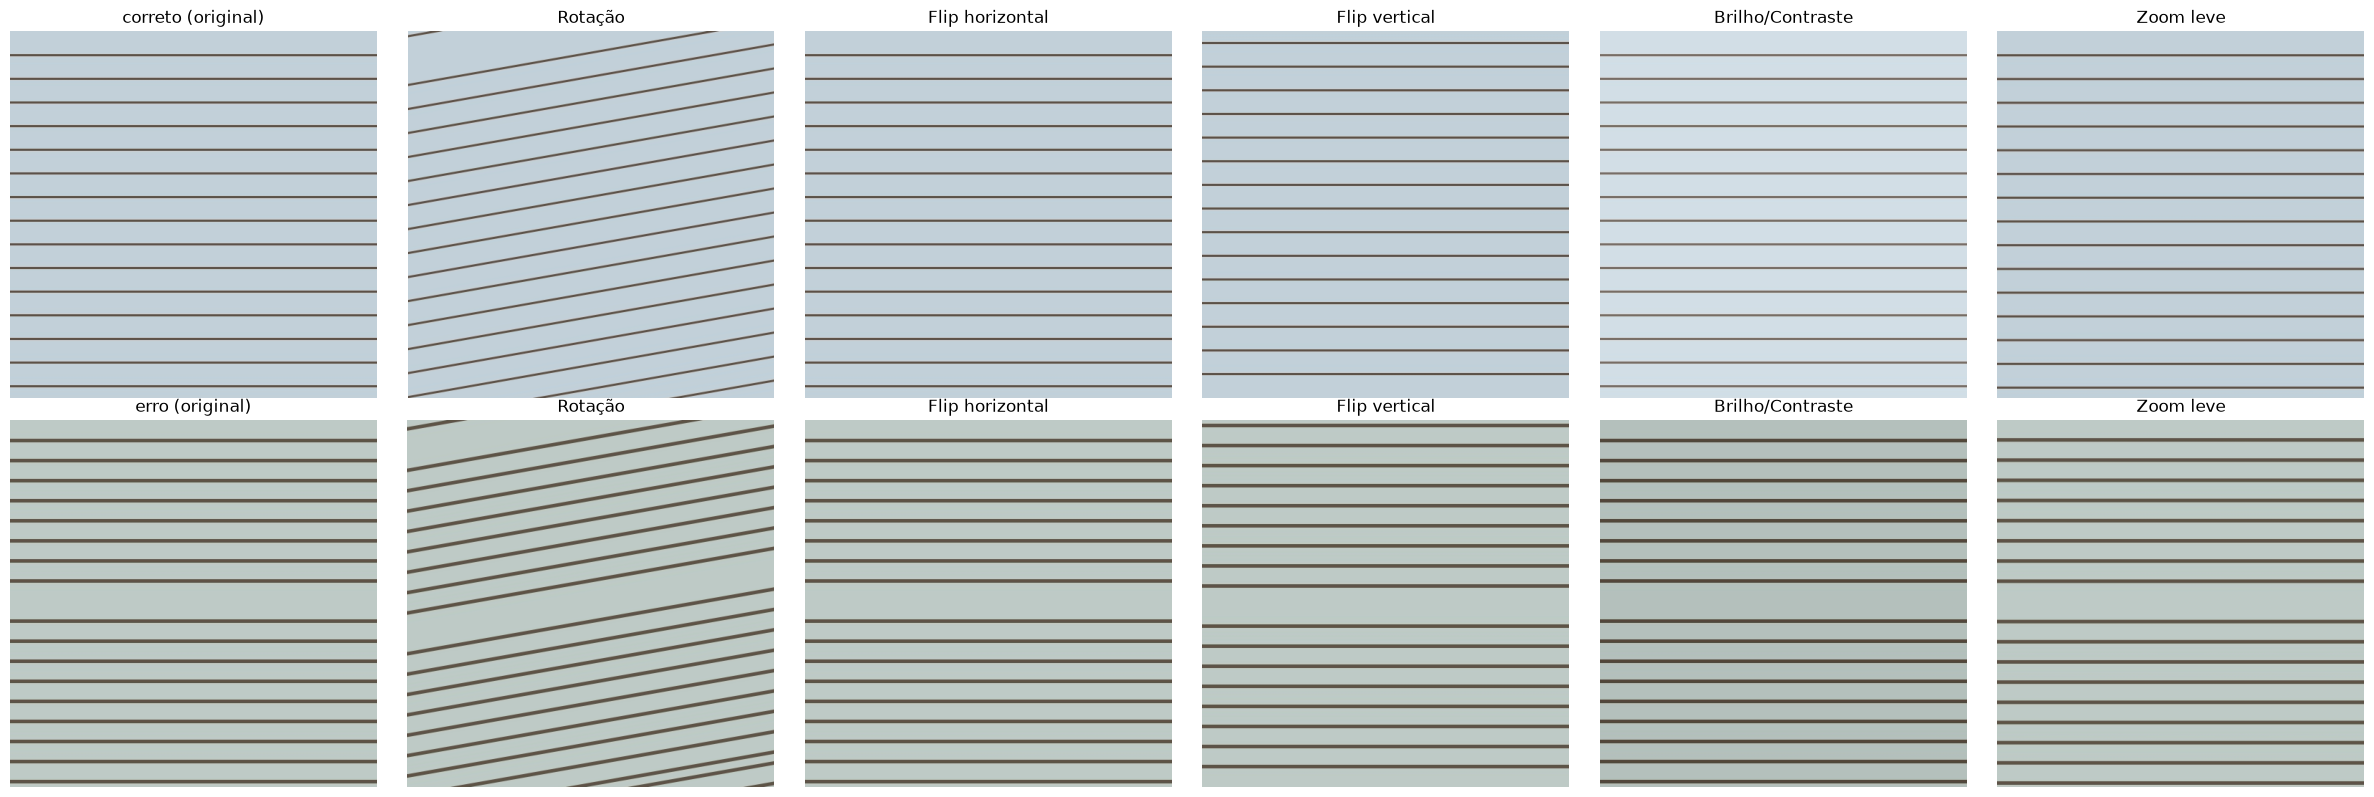

In [4]:
# Organiza as duas imagens de exemplo com seus respectivos nomes de
# classe, para iterar de forma generica na montagem do grid.
imagens_exemplo = {
    "correto": img_correto,
    "erro": img_erro,
}

# Numero de colunas = 1 (imagem original) + quantidade de transformacoes.
n_colunas = 1 + len(transformacoes)
n_linhas = len(imagens_exemplo)

plt.figure(figsize=(4 * n_colunas, 4 * n_linhas))

indice_subplot = 1
for nome_classe, imagem in imagens_exemplo.items():
    # Primeira coluna: imagem original, sem nenhuma transformacao --
    # serve de referencia visual para comparar com as demais colunas.
    plt.subplot(n_linhas, n_colunas, indice_subplot)
    plt.imshow(imagem)
    plt.title(f"{nome_classe} (original)")
    plt.axis("off")
    indice_subplot += 1

    # Demais colunas: aplica cada transformacao definida na celula
    # anterior, uma de cada vez, sobre a MESMA imagem original --
    # assim cada coluna isola o efeito de uma unica transformacao,
    # facilitando a inspecao visual individual de cada uma.
    for nome_transform, transform in transformacoes.items():
        # albumentations espera receber a imagem via parametro "image"
        # e devolve um dicionario -- o resultado transformado fica na
        # chave "image" desse dicionario.
        resultado = transform(image=imagem)
        imagem_transformada = resultado["image"]

        plt.subplot(n_linhas, n_colunas, indice_subplot)
        plt.imshow(imagem_transformada)
        plt.title(nome_transform)
        plt.axis("off")
        indice_subplot += 1

plt.tight_layout()
plt.show()